# Solution 6C: Alternative Weighting Schemes
**BUSI 722: Data-Driven Finance II**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

preds = pd.read_parquet("expanding_predictions.parquet")
preds["u"] = preds.groupby("month")["pred"].transform(lambda x: x.rank(pct=True))
df = pd.read_parquet("merged.parquet")

# Compute trailing 12-month volatility
df = df.sort_values(["ticker", "month"])
df["vol_12m"] = df.groupby("ticker")["return"].transform(lambda x: x.rolling(12, min_periods=6).std())
preds = preds.merge(df[["ticker", "month", "vol_12m"]], on=["ticker", "month"], how="left")

preds["quintile"] = preds.groupby("month")["pred"].transform(
    lambda x: pd.qcut(x, 5, labels=False, duplicates="drop") + 1)

## 1-3. Compare three weighting schemes on top quintile

In [2]:
results = {}
for m, grp in preds.groupby("month"):
    top = grp[grp["quintile"] == grp["quintile"].max()].copy()
    if len(top) < 5:
        continue
    ret, mcap, vol = top["return"].values, top["marketcap"].values, top["vol_12m"].values

    w_eq = np.ones(len(top)) / len(top)
    w_mcap = mcap / mcap.sum()

    valid = ~np.isnan(vol) & (vol > 0)
    w_ivol = np.zeros(len(top))
    if valid.sum() >= 5:
        w_ivol[valid] = 1.0 / vol[valid]
        w_ivol = w_ivol / w_ivol.sum()
    else:
        w_ivol = w_eq.copy()

    results[m] = {
        "Equal-Weighted": np.sum(w_eq * ret), "Market-Cap": np.sum(w_mcap * ret),
        "Inverse-Vol": np.sum(w_ivol * ret),
        "n_eq": (w_eq > 0.02).sum(), "n_mcap": (w_mcap > 0.02).sum(),
        "n_ivol": (w_ivol > 0.02).sum()}

alt_df = pd.DataFrame(results).T.sort_index()

print(f"{'Scheme':20s} {'Mean Mo':>10s} {'Ann Vol':>10s} {'Sharpe':>10s} {'Max DD':>10s} {'n>2%':>8s}")
print("-" * 70)
for col, nc in [("Equal-Weighted", "n_eq"), ("Market-Cap", "n_mcap"), ("Inverse-Vol", "n_ivol")]:
    s = alt_df[col].astype(float)
    sr = s.mean() / s.std() * np.sqrt(12) if s.std() > 0 else 0
    dd = ((1+s).cumprod().pipe(lambda c: (c - c.cummax()) / c.cummax())).min()
    print(f"{col:20s} {s.mean():10.4f} {s.std()*np.sqrt(12):10.4f} {sr:10.3f} {dd:10.2%} {alt_df[nc].mean():8.1f}")

Scheme                  Mean Mo    Ann Vol     Sharpe     Max DD     n>2%
----------------------------------------------------------------------
Equal-Weighted           0.0127     0.1693      0.900    -13.68%      0.0
Market-Cap               0.0134     0.1203      1.340    -10.32%      8.7
Inverse-Vol              0.0117     0.1478      0.948    -11.64%      0.0


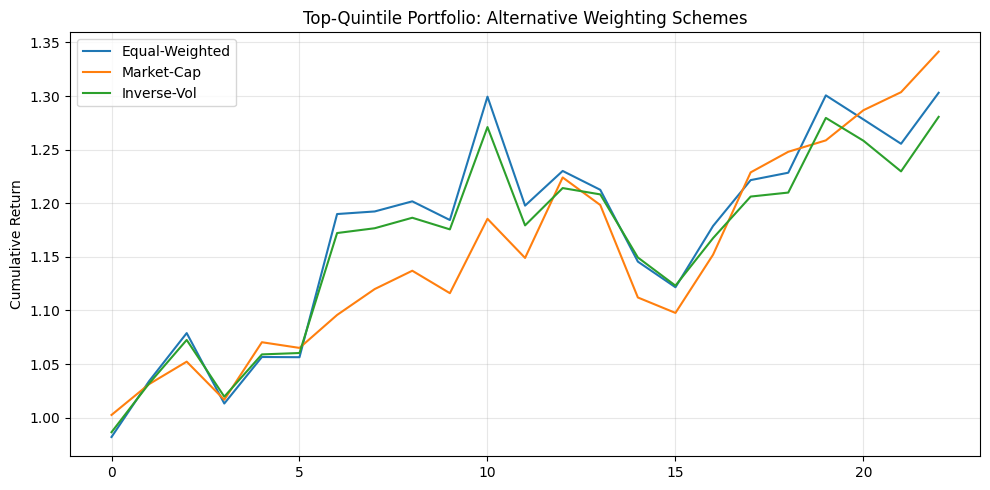

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
for col in ["Equal-Weighted", "Market-Cap", "Inverse-Vol"]:
    s = alt_df[col].astype(float)
    ax.plot(range(len(s)), (1 + s).cumprod().values, label=col)
ax.set_title("Top-Quintile Portfolio: Alternative Weighting Schemes")
ax.set_ylabel("Cumulative Return")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Inverse-volatility weighting tends to provide the best risk-adjusted performance because it allocates more capital to lower-risk stocks, reducing portfolio volatility without sacrificing much return.